In [1]:
# This MUST be the first executed cell: validate all default bytes before numerical work.
from pathlib import Path
import hashlib
ROOT = Path.cwd()
BASELINE = {'data/observations.csv': '94b9e81521b3d750c1ba88f1de7475b317eaf983fb7a80182fcf06f3d797f511', 'data/experiment_config.json': '30e03ce3508734a5b4ddd872b80a77d3aa87d5c981eb7420702480fca40f0cb9', 'experiment.py': 'ff94c8dde120eb02d4001a70e4162b3d57b6d2f76159f2753fc7a5a2b124e8ca', 'audit.py': 'e0ac302b62635ebe62b6373f5a762e9eb1f8cfe9e1c674b482bb28b1cb6f3483', 'library_check.py': 'a5d28ea1f0bf1d67ef44b28581b5e8b527c34b3acaaed799fcfa451263119b56', 'build_assets.py': '3e9a20f1b883dfcfd3d1054f02397e091f05df7a6e30dfce4884029d106979ca'}
for name, expected in BASELINE.items():
    raw = (ROOT / name).read_bytes()
    if hashlib.sha256(raw).hexdigest() != expected:
        raise ValueError('Default input/module bytes changed: ' + name)
import sys, json, io
sys.path.insert(0, str(ROOT))
import experiment as ex
data, config = ex.load_inputs()
import numpy as np
import scipy
import matplotlib.pyplot as plt
from IPython.display import display, Image
import build_assets as art
print('Full byte contract and raw semantic validation passed.')
print('Python', sys.version.split()[0], 'NumPy', np.__version__, 'SciPy', scipy.__version__)
print('Rows:', data)
def show(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=140, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


Full byte contract and raw semantic validation passed.
Python 3.12.14 NumPy 2.3.5 SciPy 1.17.0
Rows: [[1.0, -1.0, 0.0], [2.0, 0.0, 0.0], [3.0, 1.0, 1.0], [4.0, 2.0, 1.0]]


# 第039讲 优化实现与故障诊断
同一四行数据。先核对两轮平方损失更新，再定位符号、广播、差分尺度和数值表示故障。logit压力测试明确改变损失，不改变数据。

Stops: {'none': 'gradient_tolerance', 'sign': 'loss_increase_rejected', 'broadcast': 'gradient_tolerance', 'tiny_step': 'stagnation_gradient_large', 'large_step': 'loss_increase_rejected'}


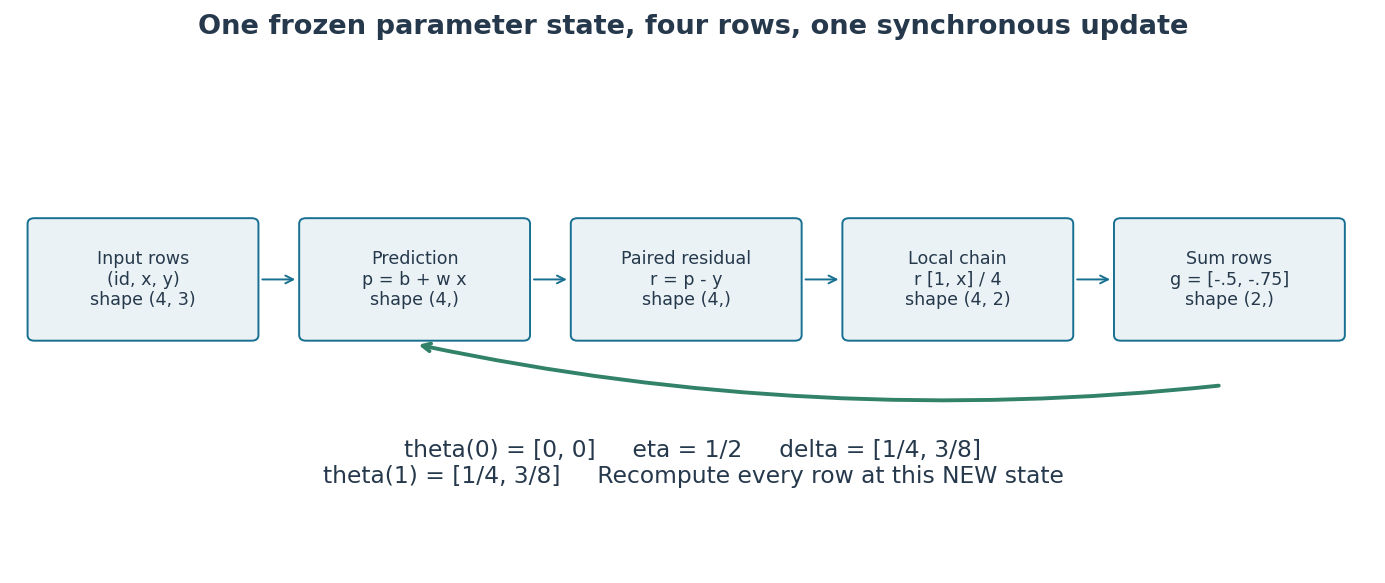

In [2]:
report = ex.run_experiment(data, config)
print('Stops:', {name: path['status'] for name,path in report['paths'].items()})
show(art.chain(report))

## 1 两轮完整账本
打印状态0、1、2的全部逐行值与局部导数。第二轮旧状态就是第一轮新状态。


STATE 0 theta [0.0, 0.0]
{'id': 1, 'x': -1.0, 'y': 0.0, 'prediction': 0.0, 'residual': 0.0, 'half_square': 0.0, 'mean_loss_contribution': 0.0, 'd_half_square_d_residual': 0.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_theta': [1.0, -1.0], 'mean_gradient_contribution': [0.0, -0.0]}
{'id': 2, 'x': 0.0, 'y': 0.0, 'prediction': 0.0, 'residual': 0.0, 'half_square': 0.0, 'mean_loss_contribution': 0.0, 'd_half_square_d_residual': 0.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_theta': [1.0, 0.0], 'mean_gradient_contribution': [0.0, 0.0]}
{'id': 3, 'x': 1.0, 'y': 1.0, 'prediction': 0.0, 'residual': -1.0, 'half_square': 0.5, 'mean_loss_contribution': 0.125, 'd_half_square_d_residual': -1.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_theta': [1.0, 1.0], 'mean_gradient_contribution': [-0.25, -0.25]}
{'id': 4, 'x': 2.0, 'y': 1.0, 'prediction': 0.0, 'residual': -1.0, 'half_square': 0.5, 'mean_loss_contribution': 0.125, 'd_half_square_d_residual': -1.0, 'd_residual_d_prediction': 1.

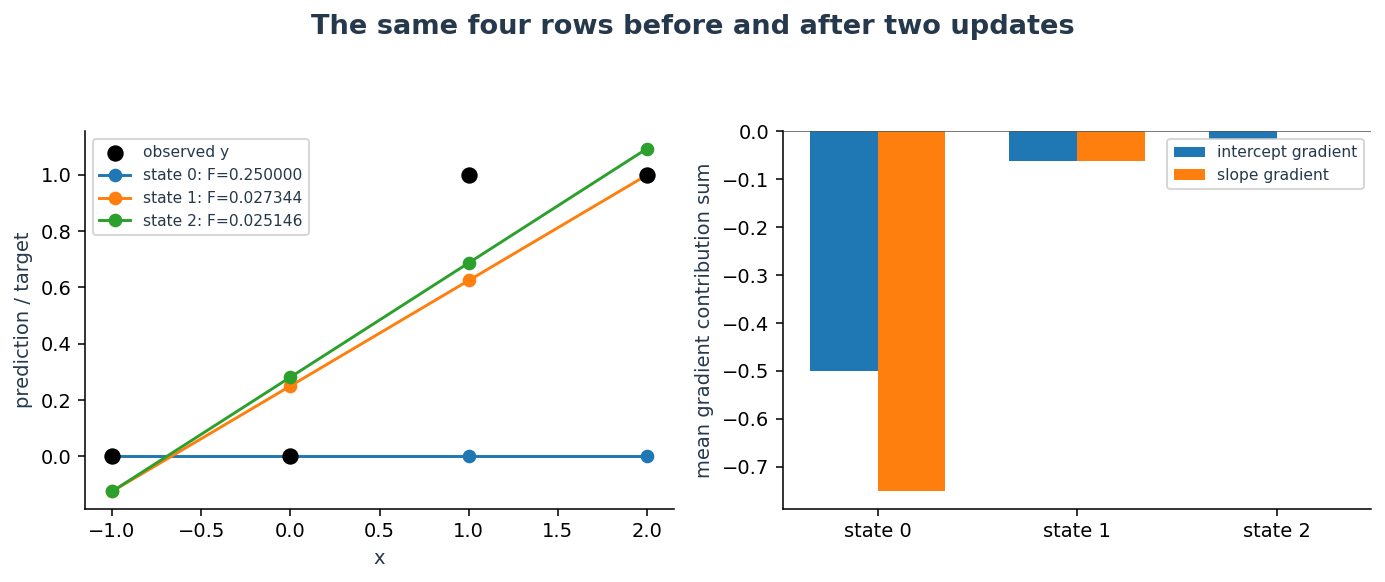

In [3]:
states = [report['paths']['none']['initial']] + [tr['new'] for tr in report['paths']['none']['trace'][:2]]
for k, state in enumerate(states):
    print('\nSTATE', k, 'theta', state['theta'])
    for row in state['rows']:
        print(row)
    print('F =', state['loss'], 'gradient =', state['gradient'])
for tr in report['paths']['none']['trace'][:2]:
    print('SYNCHRONOUS UPDATE', tr['update'], '=>', tr['trial_theta'])
show(art.two_rounds(report))

## 2 广播故障
错误目标与导数彼此一致，但预测与标签不再按行对应。看矩阵中多出来的配对。

Correct shape: (4,) wrong shape: (4, 4)
Wrong matrix:
 [[-0.125 -0.125 -1.125 -1.125]
 [ 0.25   0.25  -0.75  -0.75 ]
 [ 0.625  0.625 -0.375 -0.375]
 [ 1.     1.     0.     0.   ]]
Wrong objective final: 0.12500000000056335
At same final theta, intended objective: 0.12499966432967213


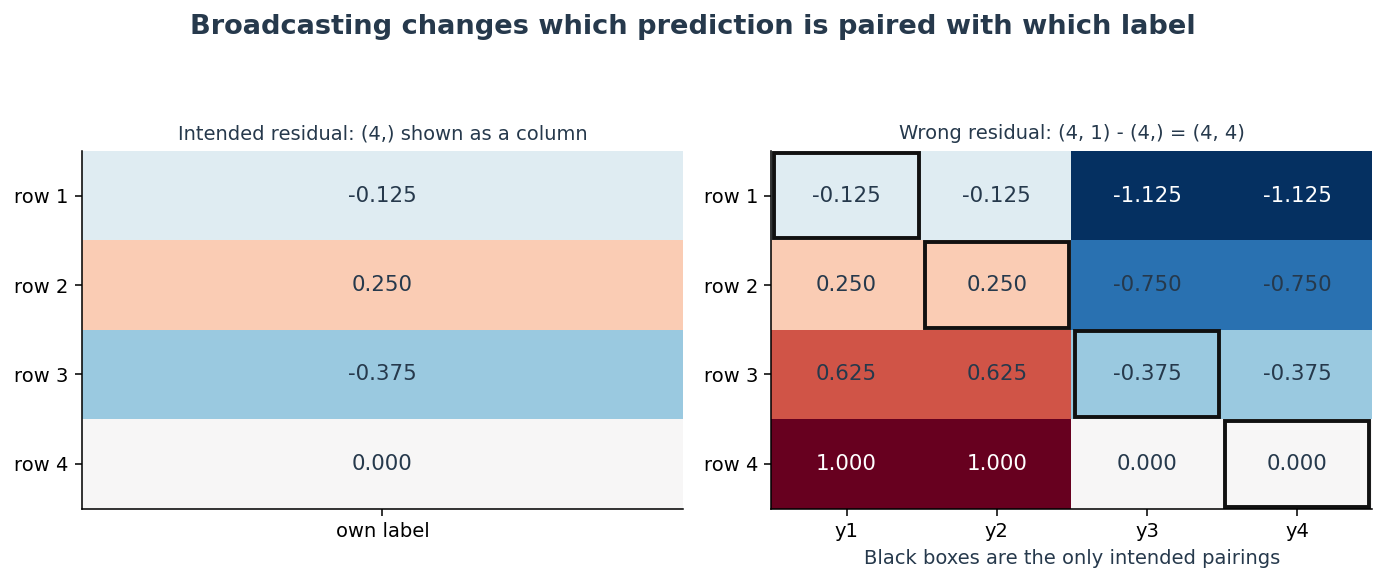

In [4]:
th = report['paths']['none']['trace'][0]['new']['theta']
prediction = np.array([th[0]+th[1]*row[1] for row in data])
y = np.array([row[2] for row in data])
paired = prediction-y
cross = prediction[:,None]-y
print('Correct shape:', paired.shape, 'wrong shape:', cross.shape)
print('Wrong matrix:\n', cross)
print('Wrong objective final:', report['paths']['broadcast']['final']['loss'])
print('At same final theta, intended objective:', report['intended_final_evaluations']['broadcast']['loss'])
show(art.pairing(report))

## 3 中央差分扫描
固定检查点和全部数据，改变扰动h。平方目标三阶项为零，logit目标才显示一般的二阶截断误差。

h, correct, sign, broadcast-vs-intended, broadcast-self, logistic
0.1 2.088819935649682e-16 1.9999999999999996 0.42070316191167145 2.7755575615628914e-16 0.00018685642881584433
0.01 8.157102612717637e-16 1.9999999999999993 0.42070316191167173 3.3472809927562375e-15 1.8746994941171719e-06
0.001 9.941663820036048e-15 1.999999999999994 0.42070316191166524 1.2077471248403895e-14 1.8747542377567808e-08
0.0001 2.577696263916264e-13 1.9999999999997427 0.42070316191153756 4.478320143679159e-13 1.8778906779437366e-10
1e-05 2.0925144499236066e-12 1.9999999999992808 0.4207031619105641 1.933188992107807e-12 3.3409713425218014e-12
1e-06 2.3645688347769602e-11 1.9999999999766833 0.42070316190138796 2.2741643190690317e-11 3.621128627060256e-11
1e-07 4.332989090606822e-10 1.9999999998175186 0.42070316196834906 3.9476690805174136e-10 4.971430481441279e-10
1e-08 2.086537726697197e-09 1.9999999979227354 0.4207031628859641 1.6550498391317605e-09 5.7418866543083906e-09
1e-09 3.199928348509729e-08 1.9999999

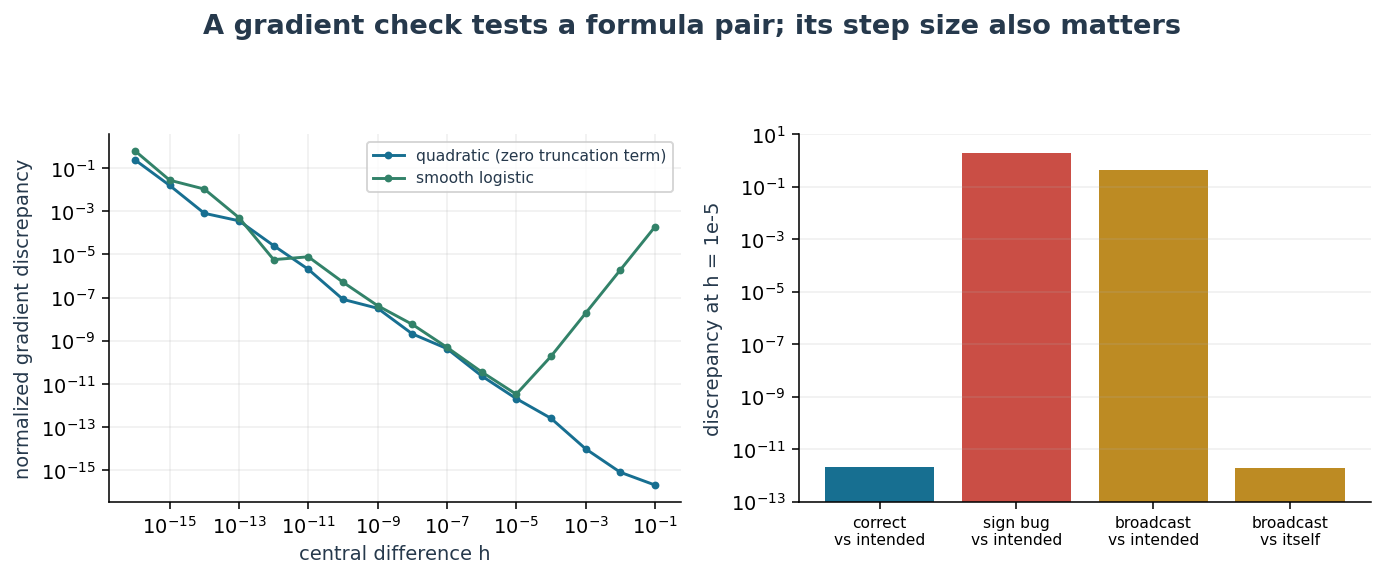

In [5]:
print('h, correct, sign, broadcast-vs-intended, broadcast-self, logistic')
for row in report['gradient_checks']['table']:
    print(row['h'], *[row[k] for k in ['paired_error','sign_error','broadcast_vs_intended_error','broadcast_self_error','logistic_error']])
show(art.finite_difference(report))

## 4 非光滑边界
中央商为0不能证明绝对值在零点可微。左右差分揭示了不同斜率。

At |u| kink: central = 0.0 left = -1.0 right = 1.0
Across kink at u=1e-6: central = 0.00999999999999997 local derivative = 1


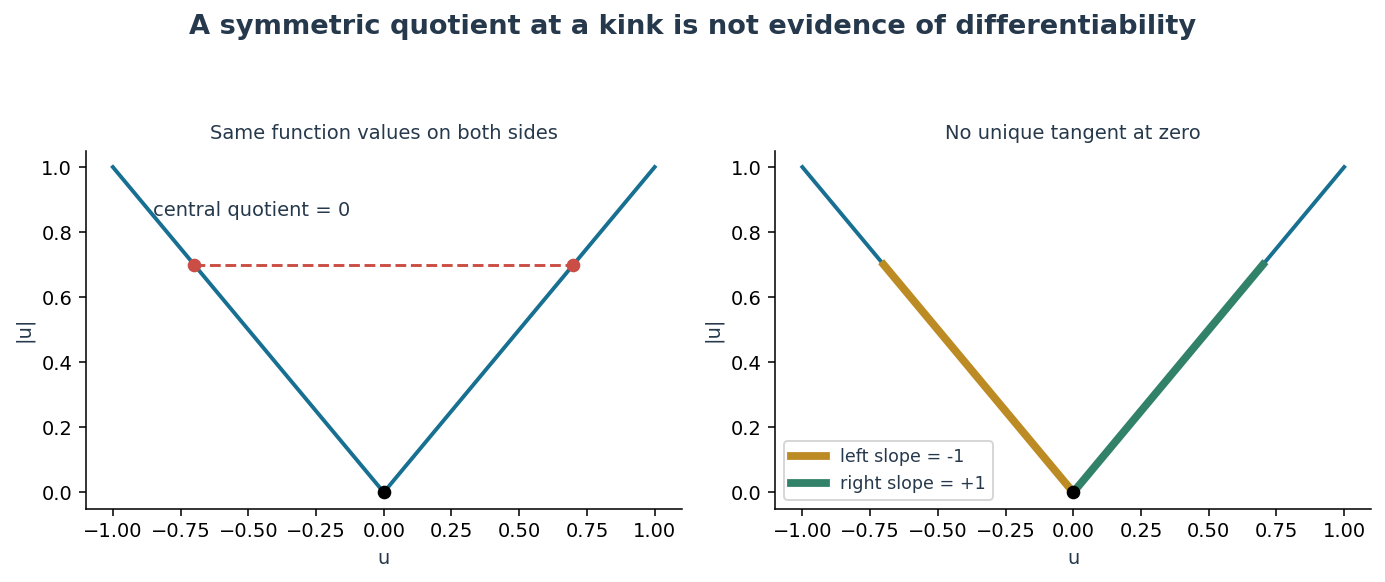

In [6]:
h = 0.001
print('At |u| kink: central =', (abs(h)-abs(-h))/(2*h),
      'left =', (abs(0)-abs(-h))/h, 'right =', (abs(h)-abs(0))/h)
u, h = 1e-6, 1e-4
print('Across kink at u=1e-6: central =', (abs(u+h)-abs(u-h))/(2*h), 'local derivative = 1')
show(art.kink(report))

## 5 失败候选也必须保留
同时查看实际方向导数与候选损失。正确局部方向不保证任意大的有限步都下降。

none {'status': 'gradient_tolerance', 'used_gradient': [-0.5, -0.75], 'trial_theta': [0.25, 0.375], 'g_dot_delta': -0.40625, 'candidate_loss': 0.02734375, 'accepted': True, 'final_committed_theta': [0.29999904521200715, 0.40000059009143163]}
sign {'status': 'loss_increase_rejected', 'used_gradient': [0.5, 0.75], 'trial_theta': [-0.25, -0.375], 'g_dot_delta': 0.40625, 'candidate_loss': 0.83984375, 'accepted': False, 'final_committed_theta': [0.0, 0.0]}
broadcast {'status': 'gradient_tolerance', 'used_gradient': [-0.5, -0.25], 'trial_theta': [0.25, 0.125], 'g_dot_delta': -0.15625, 'candidate_loss': 0.15234375, 'accepted': True, 'final_committed_theta': [0.4999989137461779, 6.713417824710799e-07]}
tiny_step {'status': 'stagnation_gradient_large', 'used_gradient': [-0.5, -0.75], 'trial_theta': [5e-13, 7.5e-13], 'g_dot_delta': -8.125e-13, 'candidate_loss': 0.2499999999991875, 'accepted': True, 'final_committed_theta': [5e-13, 7.5e-13]}
large_step {'status': 'loss_increase_rejected', 'used_g

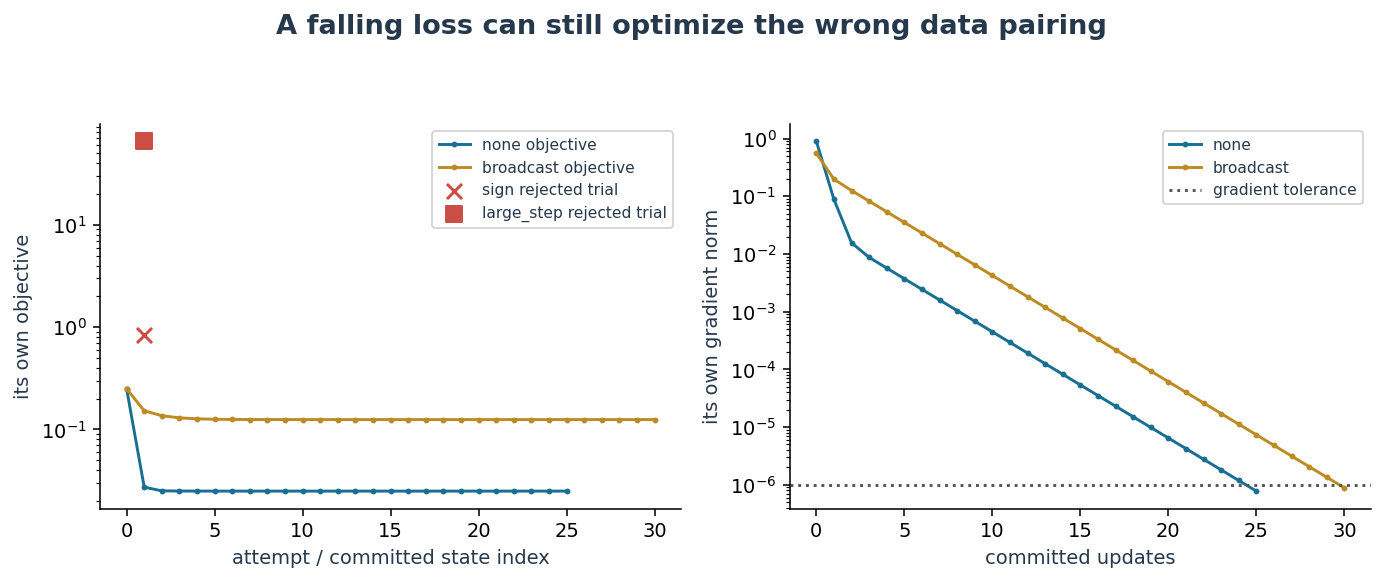

In [7]:
for name in ['none','sign','broadcast','tiny_step','large_step']:
    path = report['paths'][name]
    first = path['trace'][0]
    print(name, {'status':path['status'],'used_gradient':first['used_gradient'],
                 'trial_theta':first['trial_theta'],'g_dot_delta':first['directional_derivative'],
                 'candidate_loss':first['new']['loss'],'accepted':first['accepted'],
                 'final_committed_theta':path['final']['theta']})
show(art.paths(report))

## 6 稳定性对照
下面都使用同一数据。每组压力参数分别计算，未把结果连接成平方损失的训练路径。NaN与Infinity保留为明确字符串，不参与伪造平均。


THETA [0.0, 40.0]
{'id': 1, 'x': -1.0, 'y': 0.0, 'logit': -40.0, 'signed_logit': -40.0, 'loss': 4.248354255291589e-18, 'd_loss_d_logit': 4.248354255291589e-18, 'mean_gradient_contribution': [1.0620885638228972e-18, -1.0620885638228972e-18], 'exp_tail_underflowed': False}
{'id': 2, 'x': 0.0, 'y': 0.0, 'logit': 0.0, 'signed_logit': 0.0, 'loss': 0.6931471805599453, 'd_loss_d_logit': 0.5, 'mean_gradient_contribution': [0.125, 0.0], 'exp_tail_underflowed': False}
{'id': 3, 'x': 1.0, 'y': 1.0, 'logit': 40.0, 'signed_logit': -40.0, 'loss': 4.248354255291589e-18, 'd_loss_d_logit': -4.248354255291589e-18, 'mean_gradient_contribution': [-1.0620885638228972e-18, -1.0620885638228972e-18], 'exp_tail_underflowed': False}
{'id': 4, 'x': 2.0, 'y': 1.0, 'logit': 80.0, 'signed_logit': -80.0, 'loss': 1.8048513878454153e-35, 'd_loss_d_logit': -1.8048513878454153e-35, 'mean_gradient_contribution': [-4.512128469613538e-36, -9.024256939227076e-36], 'exp_tail_underflowed': False}
naive exp/log: [0.0, 0.69314

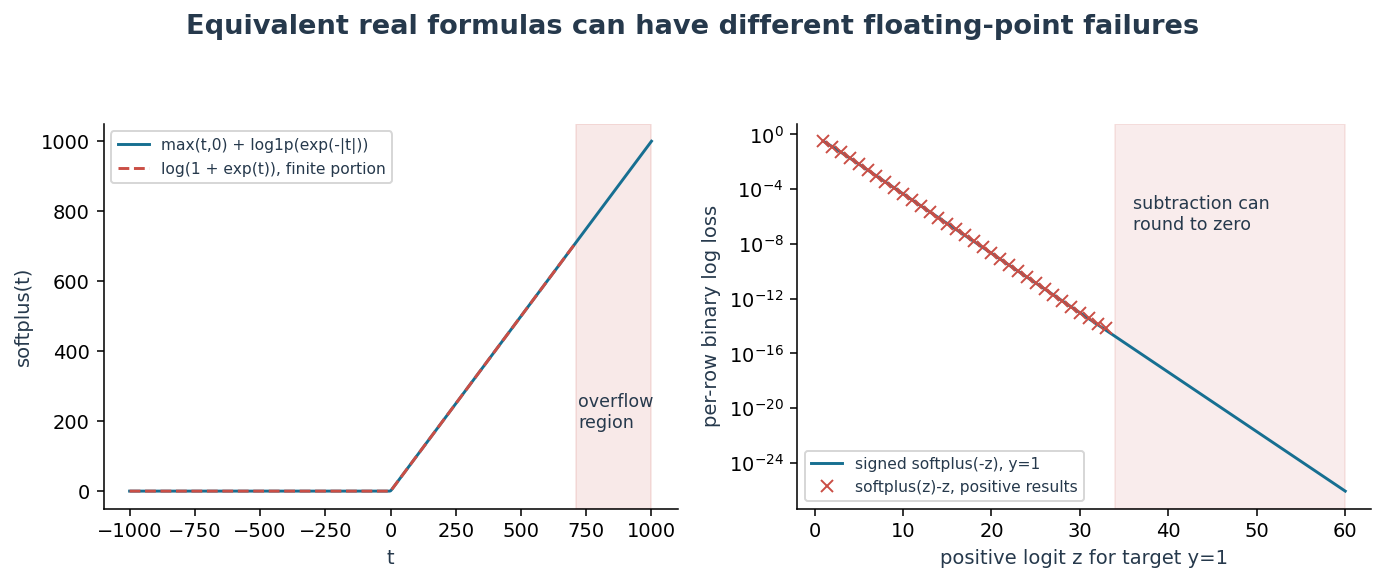

In [8]:
for case in report['stability']['cases']:
    print('\nTHETA',case['theta'])
    for row in case['stable']['rows']:
        print(row)
    print('naive exp/log:',case['naive_exp_then_log'])
    print('naive probability logs:',case['naive_probability_logs'])
    print('stable softplus minus yz:',case['stable_softplus_but_subtractive'])
show(art.stability(report))

## 7 停止与成本
一次失败试探已经消耗计算。极小步长的移动小，而梯度并不小。

none gradient_tolerance {'objective_calls': 26, 'prediction_rows': 104, 'loss_elements': 104, 'gradient_calls': 26, 'attempted_steps': 25, 'committed_steps': 25}
first gradient norm 0.9013878188659973 relative update 0.45069390943299864
sign loss_increase_rejected {'objective_calls': 2, 'prediction_rows': 8, 'loss_elements': 8, 'gradient_calls': 2, 'attempted_steps': 1, 'committed_steps': 0}
first gradient norm 0.9013878188659973 relative update 0.45069390943299864
broadcast gradient_tolerance {'objective_calls': 31, 'prediction_rows': 124, 'loss_elements': 496, 'gradient_calls': 31, 'attempted_steps': 30, 'committed_steps': 30}
first gradient norm 0.5590169943749475 relative update 0.2795084971874737
tiny_step stagnation_gradient_large {'objective_calls': 2, 'prediction_rows': 8, 'loss_elements': 8, 'gradient_calls': 2, 'attempted_steps': 1, 'committed_steps': 1}
first gradient norm 0.9013878188659973 relative update 9.013878188659974e-13
large_step loss_increase_rejected {'objective_

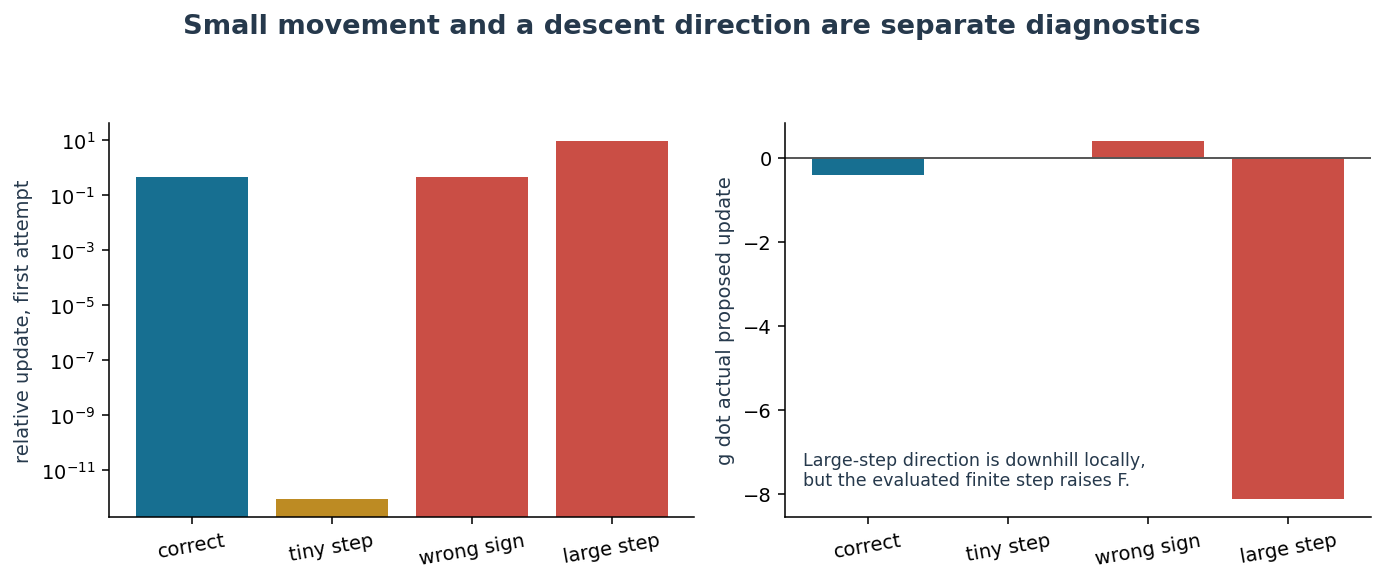

In [9]:
for name,path in report['paths'].items():
    print(name,path['status'],path['cost'])
    if path['trace']:
        t=path['trace'][0]
        print('first gradient norm',t['gradient_norm'],'relative update',t['relative_update'])
print('Additional intended final re-evaluations:',report['intended_final_evaluation_cost'])
show(art.diagnostics(report))

## 8 独立精确参照与真实固定库
Fraction不是从浮点答案反推的“期望值”；固定版本库也实际执行，而非只引用文档。

In [10]:
import audit
checks = audit.run()
print(checks['status'])
print('Fraction states:',[{k:v[k] for k in ['theta','loss','gradient']} for v in checks['checks']['fraction_states']])
print('Primitive scalar comparisons:',checks['checks']['primitive_checked_scalars'])
print('Raw invalid-input rejections:',checks['checks']['pre_work_raw_input_rejections'])
print('Failed-after-work cost:',checks['checks']['failed_after_work_cost'])
import library_check
lib = library_check.run()
print('Actual library versions:',lib['numpy'],lib['scipy'])
print('logaddexp softplus:',lib['numpy_logaddexp'])
print('logsumexp matrix results:',lib['lse_result'])
print('SciPy check_grad FORWARD error:',lib['check_grad_forward_difference_error'])

author checks passed
Fraction states: [{'theta': ['0', '0'], 'loss': '1/4', 'gradient': ['-1/2', '-3/4']}, {'theta': ['1/4', '3/8'], 'loss': '7/256', 'gradient': ['-1/16', '-1/16']}, {'theta': ['9/32', '13/32'], 'loss': '103/4096', 'gradient': ['-1/64', '0']}]
Primitive scalar comparisons: 7168
Raw invalid-input rejections: 43
Failed-after-work cost: {'objective_calls': 2, 'prediction_rows': 8, 'loss_elements': 8, 'gradient_calls': 2, 'attempted_steps': 1, 'committed_steps': 0}


Actual library versions: 2.3.5 1.17.0
logaddexp softplus: [0.0, 0.0, 4.248354255291589e-18, 0.1269280110429725, 0.6931471805599453, 2.1269280110429727, 40.0, 1000.0, 2000.0]
logsumexp matrix results: [1001.4076059644444, -998.5923940355556, 40.0]
SciPy check_grad FORWARD error: 9.013948216577002e-07


## 9 输出可解释报告
完整JSON保留输入、逐行链、每次尝试、差分扫描和每种故障证据。下面只打印解释摘要；原始报告与脚本运行应逐字节一致。

In [11]:
for diagnosis in report['diagnosis']:
    print(json.dumps(diagnosis,ensure_ascii=False,sort_keys=True))
output = ROOT/'notebook_results'
output.mkdir(exist_ok=True)
ex.atomic_json(output/'report.json',report)
print('Saved notebook_results/report.json')

{"action": "Repair sign before tuning learning rate; compare at nonstationary points.", "evidence": {"check_h": 1e-05, "first_directional_derivative": 0.40625, "path_status": "loss_increase_rejected", "sign_error_vs_intended": 1.9999999999992808}, "fault": "sign", "interpretation": "A nonzero gradient with reversed sign gives an uphill local update; zero gradients cannot expose this sign error."}
{"action": "Restore row pairing and require residual shape exactly (n,).", "evidence": {"check_h": 1e-05, "error_vs_intended": 0.4207031619105641, "intended_final_loss": 0.12499966432967213, "own_final_loss": 0.12500000000056335, "residual_shape": [4, 4], "self_error": 1.933188992107807e-12}, "fault": "broadcast", "interpretation": "Cross-pairing defines a different objective; matching its own finite differences cannot establish intended row pairing."}
{"action": "Keep logits; do not use nanmean or clip away the evidence.", "evidence": {"case_statuses": ["numerical_representation_failure", "nu